In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('data/spam.csv')
df.sample(5)

,Category,Message
668,ham,This pay is &lt;DECIMAL&gt; lakhs:)
3069,ham,Boy you best get yo ass out here quick
4506,spam,Mobile Club: Choose any of the top quality ite...
1957,ham,K...k:)why cant you come here and search job:)
3110,ham,Lol I was gonna last month. I cashed some in b...


In [12]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df['Message'],df['Category'],test_size=0.2,random_state=5)

<h1>transforming the features</h1>

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
x_train_count=cv.fit_transform(x_train)
x_test_count=cv.transform(x_test)

In [15]:
x_train_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4457, 7705))

In [18]:
len(x_train_count.toarray()[1]) #vocabulary size is 7705(7705 unique words in the training data)

7705

<h1> training an naive bayes model</h1>

In [22]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB

In [23]:
model=MultinomialNB()
model.fit(x_train_count,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


<h1>Model evaluation</h1>

In [26]:
from sklearn.metrics import classification_report,confusion_matrix
model_pred=model.predict(x_test_count)
report=classification_report(y_test,model_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       970
        spam       0.98      0.96      0.97       145

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [25]:
model.score(x_test_count,y_test)

0.9919282511210762

<Axes: >

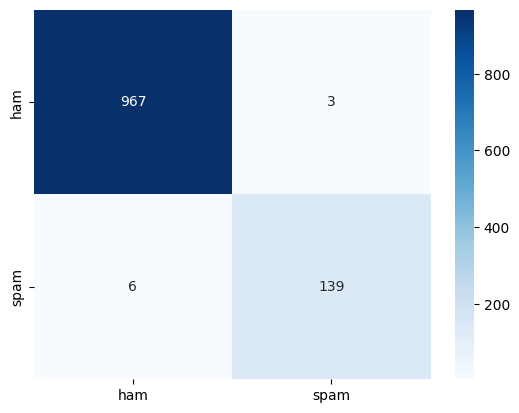

In [27]:
import seaborn as sns
cm=confusion_matrix(y_test,model_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['ham','spam'],yticklabels=['ham','spam'])

In [31]:
email=['Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C\'s apply 08452810075over18\'s'
       ,'Nah I don\'t think he goes to usf, he lives around here though']
email_count=cv.transform(email)
model.predict(email_count)

array(['spam', 'ham'], dtype='<U4')

In [33]:
model.predict_proba(email_count) # .predict_proba() gives the probability of each class for the given input.

array([[6.87489841e-24, 1.00000000e+00],
       [1.00000000e+00, 2.54999913e-11]])

In [34]:
2.54999913e-11

2.54999913e-11